In [2]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split # Tạm dùng để tách validation/test
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

In [3]:
CSV_FILE = ["/home/stock-agent/ml/stock_models/data/GOOGL_1year_monthly.csv",
            "/home/stock-agent/ml/stock_models/data/MSFT_1year_monthly.csv",
            "/home/stock-agent/ml/stock_models/data/NVDA_1year_monthly.csv"] # File CSV đã tạo từ bước trước
FEATURES = ['Open', 'High', 'Low', 'Close', 'Volume'] # Các đặc trưng sử dụng
TARGET = 'Target'
SEQUENCE_LENGTH = 6 # Sử dụng dữ liệu 6 tháng trước để dự đoán
BATCH_SIZE = 16 # Kích thước lô
HIDDEN_SIZE = 64 # Số units trong lớp LSTM
NUM_LAYERS = 2    # Số lớp LSTM chồng lên nhau
LEARNING_RATE = 0.001
EPOCHS = 100
TEST_SIZE = 0.15 # Tỷ lệ dữ liệu cho tập test
VALID_SIZE = 0.15 # Tỷ lệ dữ liệu (của phần còn lại sau test) cho tập validation
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [4]:
df_all = pd.read_csv(CSV_FILE[0], parse_dates=['Date'])
df_all.sort_values(by=['Date'], inplace=True)
df_all.head()

,Date,Close,High,Low,Open,Volume,Target
0,2004-08-01,2.549622,2.826327,2.389975,2.490595,2.672137e+09,1
1,2004-09-01,3.227811,3.362802,2.464195,2.557841,4.249914e+09,1
2,2004-10-01,4.748071,4.979945,3.210377,3.257698,1.027243e+10,0
3,2004-11-01,4.532384,5.021039,4.017579,4.820546,1.109266e+10,1
4,2004-12-01,4.801618,4.978201,4.195905,4.531637,5.807878e+09,1


In [5]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0,1))
all_data = []
for csv_file in CSV_FILE:
    df_all = pd.read_csv(csv_file, parse_dates=['Date'])
    df_all.sort_values(by=['Date'], inplace=True)
    data = df_all.filter(['Close'])
    all_data.append(data)
all_data = pd.concat(all_data, axis=0)
scaler.fit(all_data)

MinMaxScaler()

In [6]:
x_train = []
y_train = []
x_test = []
y_test = []
for csv_file in CSV_FILE:
    df_all = pd.read_csv(csv_file, parse_dates=['Date'])
    df_all.sort_values(by=['Date'], inplace=True)
    data = df_all.filter(['Close'])
    # Convert the dataframe to a numpy array
    dataset = data.values
    training_data_len = int(np.ceil( len(dataset) * .95 ))
    scaled_data = scaler.transform(dataset)
    train_data = scaled_data[0:int(training_data_len), :]
    test_data = scaled_data[training_data_len - SEQUENCE_LENGTH: , :]
    # Get the number of rows to train the model on
    for i in range(SEQUENCE_LENGTH, len(train_data)):
        x_train.append(train_data[(i-SEQUENCE_LENGTH):i, 0])
        y_train.append(train_data[i, 0])
    # y_test = np.vstack((y_test, dataset[training_data_len:, :]))
    # print(training_data_len - len(scaled_data))
    # print(y_test.shape)
    # for i in range(training_data_len, len(dataset)):
    #     y_test.append(dataset[i, :])
    for i in range(SEQUENCE_LENGTH, len(test_data)):
        x_test.append(test_data[(i-SEQUENCE_LENGTH):i, 0])
        y_test.append(test_data[i, 0])

/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


In [7]:
# Convert the data to a numpy array
x_test = np.array(x_test)
x_train = np.array(x_train)
y_train = np.array(y_train)
y_test = np.array(y_test)
# Reshape the data
# x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1 ))
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(800, 6)
(42, 6)
(800,)
(42,)


In [8]:
from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout, BatchNormalization
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.callbacks import LearningRateScheduler
from keras.optimizers import Adam
def scheduler(epoch, lr):
    if epoch > 15:
        return lr * 0.1
    return lr
lr_callback = LearningRateScheduler(scheduler)
checkpoint = ModelCheckpoint(
    filepath='./models/best_model.h5',
    monitor='val_loss',       # or 'val_accuracy'
    save_best_only=True,
    verbose=1
)
optimizer = Adam(learning_rate=0.01)
# Build the LSTM model
model = Sequential()
model.add(LSTM(128, return_sequences=True, input_shape= (x_train.shape[1], 1)))
model.add(LSTM(64, return_sequences=False))
model.add(Dense(32,activation='relu'))
model.add(Dense(1))

# Compile the model
model.compile(optimizer=optimizer, loss='mean_squared_error')

# Train the model
history = model.fit(x_train, y_train, batch_size=4, epochs=50,
                    validation_data=(x_test, y_test),
                    callbacks=[checkpoint, lr_callback])

2025-05-09 16:10:12.669915: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-05-09 16:10:12.673177: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-05-09 16:10:12.683854: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1746807012.701790  198413 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746807012.707148  198413 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1746807012.721129  198413 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

Epoch 1/50


E0000 00:00:1746807014.083444  198413 cuda_executor.cc:1228] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
E0000 00:00:1746807014.089019  198413 cuda_executor.cc:1228] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1746807014.093859  198413 gpu_device.cc:2341] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...
/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequen

199/200 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0170
Epoch 1: val_loss improved from inf to 0.01909, saving model to best_model.h5


200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0169 - val_loss: 0.0191 - learning_rate: 0.0100
Epoch 2/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0011
Epoch 2: val_loss improved from 0.01909 to 0.00474, saving model to best_model.h5


200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0011 - val_loss: 0.0047 - learning_rate: 0.0100
Epoch 3/50
199/200 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0016
Epoch 3: val_loss did not improve from 0.00474
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0016 - val_loss: 0.0162 - learning_rate: 0.0100
Epoch 4/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 7.5438e-04
Epoch 4: val_loss did not improve from 0.00474
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 7.5549e-04 - val_loss: 0.0111 - learning_rate: 0.0100
Epoch 5/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4.8622e-04
Epoch 5: val_loss improved from 0.00474 to 0.00383, saving model to best_model.h5


200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 4.8625e-04 - val_loss: 0.0038 - learning_rate: 0.0100
Epoch 6/50
199/200 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 8.5331e-04
Epoch 6: val_loss did not improve from 0.00383
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 8.5277e-04 - val_loss: 0.0077 - learning_rate: 0.0100
Epoch 7/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0011
Epoch 7: val_loss did not improve from 0.00383
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0011 - val_loss: 0.0133 - learning_rate: 0.0100
Epoch 8/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1664e-04
Epoch 8: val_loss did not improve from 0.00383
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.1706e-04 - val_loss: 0.0043 - learning_rate: 0.0100
Epoch 9/50
199/200 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.9412e-04
Epoch 9: val_loss did not improve from 0.00383
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 2.9633e-04 - val_loss: 0.0123 - learning_rate: 0.0100
Epoch 10/50
191/200 ━

200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 2.6102e-04 - val_loss: 0.0017 - learning_rate: 0.0100
Epoch 12/50
199/200 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2217e-04
Epoch 12: val_loss did not improve from 0.00174
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.2287e-04 - val_loss: 0.0057 - learning_rate: 0.0100
Epoch 13/50
195/200 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4.7669e-04
Epoch 13: val_loss improved from 0.00174 to 0.00165, saving model to best_model.h5


200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 4.7813e-04 - val_loss: 0.0016 - learning_rate: 0.0100
Epoch 14/50
197/200 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4.4989e-04
Epoch 14: val_loss did not improve from 0.00165
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 4.5126e-04 - val_loss: 0.0085 - learning_rate: 0.0100
Epoch 15/50
199/200 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5.0647e-04
Epoch 15: val_loss did not improve from 0.00165
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 5.0702e-04 - val_loss: 0.0023 - learning_rate: 0.0100
Epoch 16/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.9984e-04
Epoch 16: val_loss did not improve from 0.00165
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 3.0041e-04 - val_loss: 0.0027 - learning_rate: 0.0100
Epoch 17/50
191/200 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.4152e-04
Epoch 17: val_loss did not improve from 0.00165
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 2.3973e-04 - val_loss: 0.0035 - learning_rate: 1.0000e-03
E

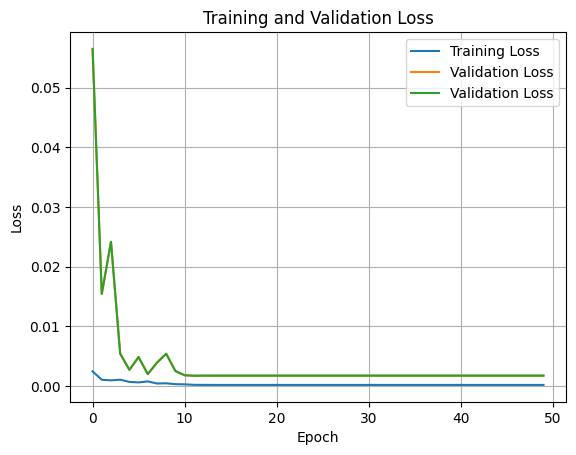

In [9]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
if 'val_loss' in history.history:
    plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
test_data = scaled_data[training_data_len - SEQUENCE_LENGTH: , :]
print(len(test_data))
# Create the data sets x_test and y_test
x_test = []
y_test = dataset[training_data_len:, :]
for i in range(SEQUENCE_LENGTH, len(test_data)):
    x_test.append(test_data[i-SEQUENCE_LENGTH:i, 0])
    
# Convert the data to a numpy array
x_test = np.array(x_test)
print(x_test.shape)
print(y_test.shape)
# Reshape the data
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1 ))

# Get the models predicted price values 
predictions = model.predict(x_test)
predictions = scaler.inverse_transform(predictions)

# Get the root mean squared error (RMSE)
rmse = np.sqrt(np.mean(((predictions - y_test) ** 2)))
rmse

(42, 6)
(42, 1)
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


19.894464915830824

In [52]:
# Eval positive/negative
ticker_counts = [0,12,15,15]
bi_preds = predictions.reshape(-1)
bi_ground_truth = y_test.reshape(-1)
accuracy = 0
for i in range(len(ticker_counts)-1):
    bi_pred = bi_preds[ticker_counts[i]:ticker_counts[i+1]+ticker_counts[i]]
    bi_pred = (bi_pred[1:] > bi_pred[:-1]).astype(int)
    bi_gt = bi_ground_truth[ticker_counts[i]:ticker_counts[i+1]+ticker_counts[i]]
    bi_gt = (bi_gt[1:] > bi_gt[:-1]).astype(int)
    accuracy += np.sum(bi_pred == bi_gt)
    


/tmp/ipykernel_24599/3096995962.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid['Predictions'] = predictions[:15]


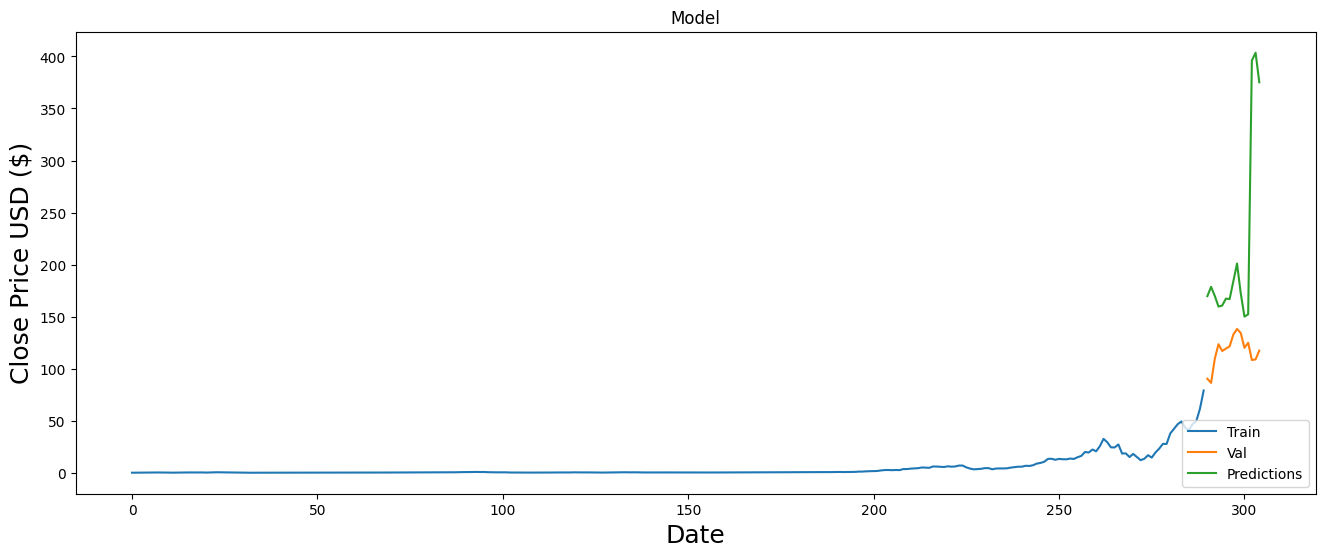

In [61]:
train = data[:training_data_len]
valid = data[training_data_len:]
valid['Predictions'] = predictions[:15]
# Visualize the data
plt.figure(figsize=(16,6))
plt.title('Model')
plt.xlabel('Date', fontsize=18)
plt.ylabel('Close Price USD ($)', fontsize=18)
plt.plot(train['Close'])
plt.plot(valid[['Close', 'Predictions']])
plt.legend(['Train', 'Val', 'Predictions'], loc='lower right')
plt.show()

In [16]:
print(predictions)

[[190.23676]
 [201.08466]
 [188.34004]
 [172.4715 ]
 [171.68594]
 [179.95593]
 [180.88191]
 [202.53587]
 [225.48526]
 [187.72069]
 [156.33638]]


In [9]:
# Lưu lại model và scalar
import joblib

# model.save("./models/model.h5")
joblib.dump(scaler, "models/scaler.save")

['models/scaler.save']

In [1]:
from tensorflow.keras.models import load_model
import joblib

scaler = joblib.load("./models/scaler.save")
# Load lại model
model = load_model("./models/model.h5")

# Kiểm tra kiến trúc
model.summary()

2025-05-09 15:00:18.043294: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-05-09 15:00:18.047110: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-05-09 15:00:18.058484: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1746802818.076714   69941 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746802818.082288   69941 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1746802818.096907   69941 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 6, 128)         │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,625 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 117,621 (459.46 KB)

 Trainable params: 117,619 (459.45 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [9]:
csv_file = CSV_FILE[1]
df_all = pd.read_csv(csv_file, parse_dates=['Date'])
df_all.sort_values(by=['Date'], inplace=True)
data = df_all.filter(['Close'])
# Convert the dataframe to a numpy array
dataset = data.values
training_data_len = int(np.ceil( len(dataset) * .95 ))
scaled_data = scaler.transform(dataset)
test_data = scaled_data[training_data_len - SEQUENCE_LENGTH: , :]
print(len(test_data))
# Create the data sets x_test and y_test
x_test = []
y_test = dataset[training_data_len:, :]
for i in range(SEQUENCE_LENGTH, len(test_data)):
    x_test.append(test_data[i-SEQUENCE_LENGTH:i, 0])
    
# Convert the data to a numpy array
x_test = np.array(x_test)

# Reshape the data
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1 ))
print(x_test.shape)
# Get the models predicted price values 
predictions = model.predict(x_test)
predictions = scaler.inverse_transform(predictions)

# Get the root mean squared error (RMSE)
rmse = np.sqrt(np.mean(((predictions - y_test) ** 2)))
rmse

21
(15, 6, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


26.740043715480677